In [ ]:
!pip install missingno

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
# data processing, CSV file I/O (e.g. pd.read_csv)

#visualization libraries
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.style as style
from matplotlib import colors
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

import plotly.express as px
import plotly.graph_objs as go
import plotly.figure_factory as ff
from plotly.subplots import make_subplots
import plotly.offline as pyo
from plotly import tools
import seaborn as sns
import missingno as msno
#for visualizing missing data

In [ ]:
data=pd.read_csv(r"/content/application_record.csv")
data

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438552,6840104,M,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.0
438553,6840222,F,N,N,0,103500.0,Working,Secondary / secondary special,Single / not married,House / apartment,-15939,-3007,1,0,0,0,Laborers,1.0
438554,6841878,F,N,N,0,54000.0,Commercial associate,Higher education,Single / not married,With parents,-8169,-372,1,1,0,0,Sales staff,1.0
438555,6842765,F,N,Y,0,72000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21673,365243,1,0,0,0,NaN,2.0


In [ ]:
data.describe(include='all')

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
count,4.385570e+05,438557,438557,438557,438557.000000,4.385570e+05,438557,438557,438557,438557,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,304354,438557.000000
unique,NaN,2,2,2,NaN,NaN,5,5,5,6,NaN,NaN,NaN,NaN,NaN,NaN,18,NaN
top,NaN,F,N,Y,NaN,NaN,Working,Secondary / secondary special,Married,House / apartment,NaN,NaN,NaN,NaN,NaN,NaN,Laborers,NaN
freq,NaN,294440,275459,304074,NaN,NaN,226104,301821,299828,393831,NaN,NaN,NaN,NaN,NaN,NaN,78240,NaN
mean,6.022176e+06,NaN,NaN,NaN,0.427390,1.875243e+05,NaN,NaN,NaN,NaN,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,NaN,2.194465
std,5.716370e+05,NaN,NaN,NaN,0.724882,1.100869e+05,NaN,NaN,NaN,NaN,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,NaN,0.897207
min,5.008804e+06,NaN,NaN,NaN,0.000000,2.610000e+04,NaN,NaN,NaN,NaN,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,NaN,1.000000
25%,5.609375e+06,NaN,NaN,NaN,0.000000,1.215000e+05,NaN,NaN,NaN,NaN,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,NaN,2.000000
50%,6.047745e+06,NaN,NaN,NaN,0.000000,1.607805e+05,NaN,NaN,NaN,NaN,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,NaN,2.000000
75%,6.456971e+06,NaN,NaN,NaN,1.000000,2.250000e+05,NaN,NaN,NaN,NaN,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,NaN,3.000000


In [ ]:
print('Number of datapoints for applications records:{}'.format(len(data)))
print('Number of unique clients in dataset:{}'.format(len(data.ID.unique())))


Number of datapoints for applications records:438557
Number of unique clients in dataset:438510


In [ ]:
records=pd.read_csv(r"/content/credit_record.csv")
records

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C
...,...,...,...
1048570,5150487,-25,C
1048571,5150487,-26,C
1048572,5150487,-27,C
1048573,5150487,-28,C


In [ ]:
print('Number of datapoints for credit records:{}'.format(len(records)))
print('Number of unique clients in dataset:{}'.format(len(records.ID.unique())))

Number of datapoints for credit records:1048575
Number of unique clients in dataset:45985


# Before removing duplicated data:

In [ ]:
len(set(records['ID']).intersection(set(data['ID'])))


36457

# After removing duplicated data

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.iloc[:,1:].duplicated().sum()

np.int64(348472)

In [ ]:
print(f'Duplicates in applications data: {data.iloc[:,1:].duplicated().sum()}, ({np.round(100*data.iloc[:,1:].duplicated().sum()/len(data),1)}%)')
print('')
print(f'Duplicates in records data: {records.duplicated().sum()},  ({np.round(100*records.duplicated().sum()/len(records),1)}%)')

Duplicates in applications data: 348472, (79.5%)

Duplicates in records data: 0,  (0.0%)


# Drop Duplicates:

In [ ]:
data=data.drop_duplicates(subset=data.columns[1:],keep='first')

In [ ]:
data.shape

(90085, 18)

In [ ]:
len(set(records['ID']).intersection(set(data['ID'])))

9709

In [ ]:
records.ID.value_counts()

,count
ID,
5016338,61
5090968,61
5095366,61
5122274,61
5045615,61
...,...
5012689,1
5012728,1
5016441,1


In [ ]:
# Finding the cardinality in the data


In [ ]:
for col in data.columns:
    print(col,data[col].nunique())

ID 90085
CODE_GENDER 2
FLAG_OWN_CAR 2
FLAG_OWN_REALTY 2
CNT_CHILDREN 12
AMT_INCOME_TOTAL 866
NAME_INCOME_TYPE 5
NAME_EDUCATION_TYPE 5
NAME_FAMILY_STATUS 5
NAME_HOUSING_TYPE 6
DAYS_BIRTH 16379
DAYS_EMPLOYED 9406
FLAG_MOBIL 1
FLAG_WORK_PHONE 2
FLAG_PHONE 2
FLAG_EMAIL 2
OCCUPATION_TYPE 18
CNT_FAM_MEMBERS 13


In [ ]:
[(col,data[col].nunique()) for col in data.columns]

[('ID', 90085),
 ('CODE_GENDER', 2),
 ('FLAG_OWN_CAR', 2),
 ('FLAG_OWN_REALTY', 2),
 ('CNT_CHILDREN', 12),
 ('AMT_INCOME_TOTAL', 866),
 ('NAME_INCOME_TYPE', 5),
 ('NAME_EDUCATION_TYPE', 5),
 ('NAME_FAMILY_STATUS', 5),
 ('NAME_HOUSING_TYPE', 6),
 ('DAYS_BIRTH', 16379),
 ('DAYS_EMPLOYED', 9406),
 ('FLAG_MOBIL', 1),
 ('FLAG_WORK_PHONE', 2),
 ('FLAG_PHONE', 2),
 ('FLAG_EMAIL', 2),
 ('OCCUPATION_TYPE', 18),
 ('CNT_FAM_MEMBERS', 13)]

In [ ]:
unique_counts=pd.DataFrame.from_records([(col,data[col].nunique()) for col in data.columns],
                                        columns=['Column_Name','Num_Unique']).sort_values(by=['Num_Unique'])
unique_counts

,Column_Name,Num_Unique
12,FLAG_MOBIL,1
1,CODE_GENDER,2
3,FLAG_OWN_REALTY,2
2,FLAG_OWN_CAR,2
14,FLAG_PHONE,2
13,FLAG_WORK_PHONE,2
15,FLAG_EMAIL,2
7,NAME_EDUCATION_TYPE,5
8,NAME_FAMILY_STATUS,5
6,NAME_INCOME_TYPE,5


In [ ]:
unique_counts=pd.DataFrame.from_records([(col,records[col].nunique()) for col in records.columns],
                                        columns=['Column_Name','Num_Unique']).sort_values(by=['Num_Unique'])
unique_counts

,Column_Name,Num_Unique
2,STATUS,8
1,MONTHS_BALANCE,61
0,ID,45985


In [ ]:
data['FLAG_MOBIL'].unique()

array([1])

In [ ]:
data.drop(['FLAG_MOBIL'],axis=1,inplace=True)

In [ ]:
data.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,0,1,1,Sales staff,1.0
7,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,0,0,0,NaN,1.0
10,5008815,M,Y,Y,0,270000.0,Working,Higher education,Married,House / apartment,-16872,-769,1,1,1,Accountants,2.0


In [ ]:
data.shape

(90085, 17)

Handling Missing Values

In [ ]:
data.isnull().sum()/len(data)*100

,0
ID,0.000000
CODE_GENDER,0.000000
FLAG_OWN_CAR,0.000000
FLAG_OWN_REALTY,0.000000
CNT_CHILDREN,0.000000
AMT_INCOME_TOTAL,0.000000
NAME_INCOME_TYPE,0.000000
NAME_EDUCATION_TYPE,0.000000
NAME_FAMILY_STATUS,0.000000
NAME_HOUSING_TYPE,0.000000


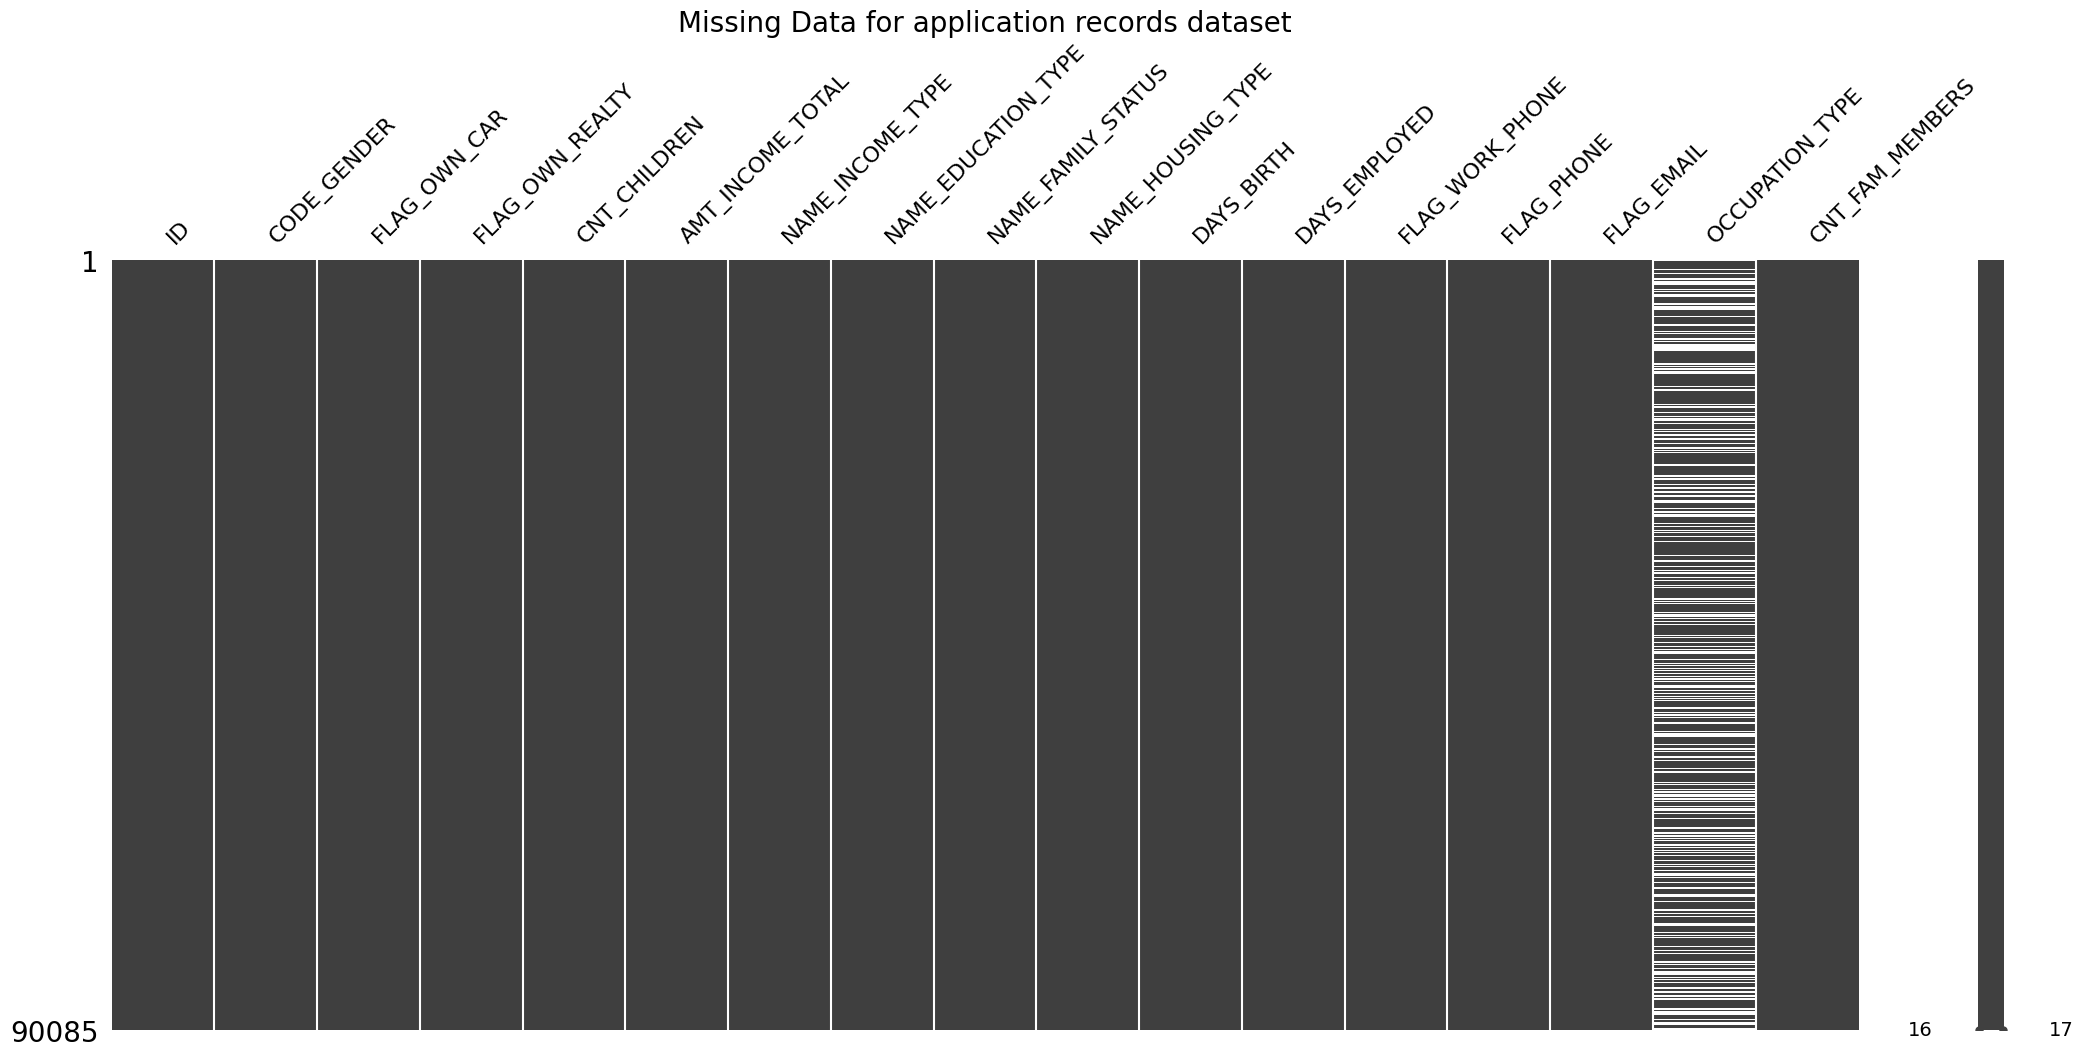

In [ ]:
missing = msno.matrix(data)
missing.set_title("Missing Data for application records dataset", fontsize= 20);

In [ ]:
records.isnull().sum()

,0
ID,0
MONTHS_BALANCE,0
STATUS,0


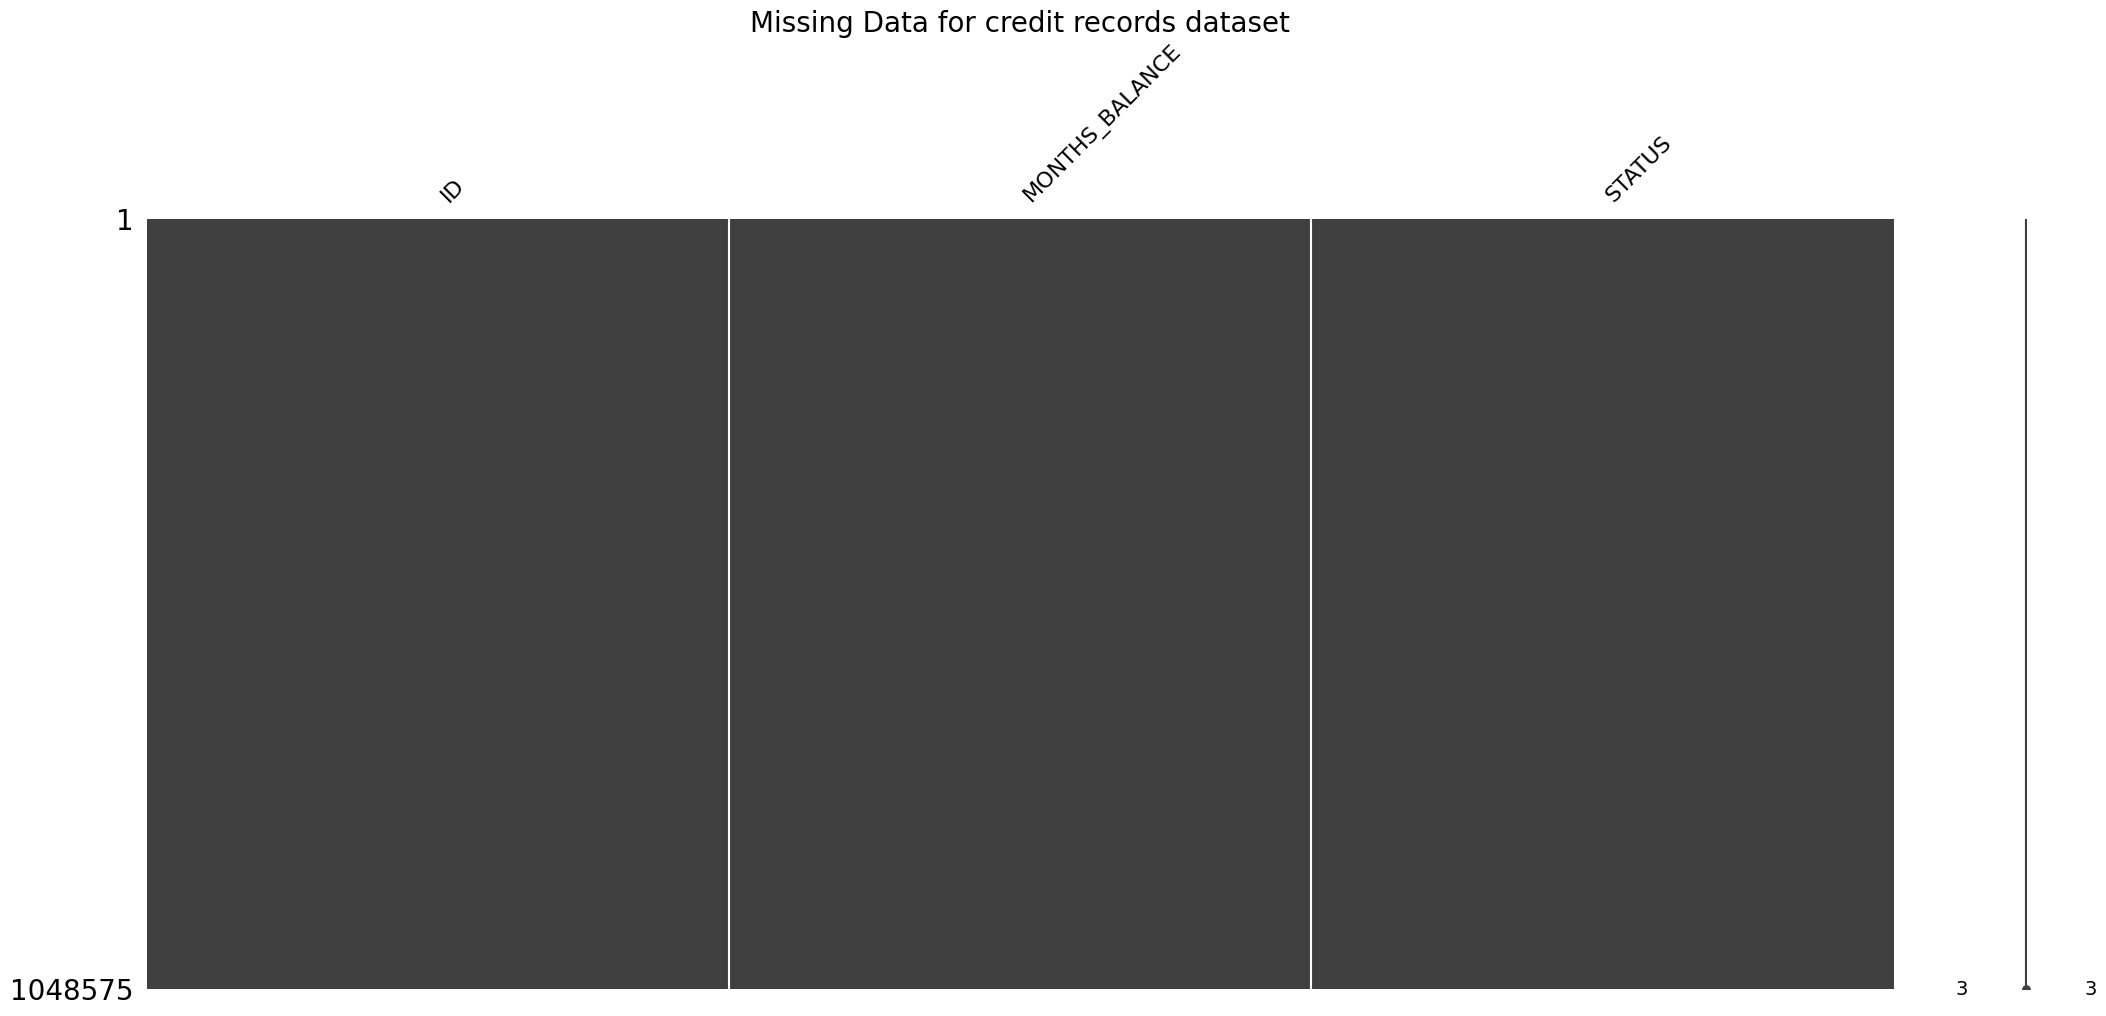

In [ ]:
missing = msno.matrix(records)
missing.set_title("Missing Data for credit records dataset", fontsize= 20);

In [ ]:
data['OCCUPATION_TYPE'].value_counts()

,count
OCCUPATION_TYPE,
Laborers,16624
Sales staff,9123
Core staff,8091
Managers,6675
Drivers,5860
High skill tech staff,3357
Accountants,3034
Medicine staff,2484
Cooking staff,1764


In [ ]:
#Fill missing values
data['OCCUPATION_TYPE'].fillna(value='Other' , inplace=True)

In [ ]:
data.isna().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


In [ ]:
records.dtypes

,0
ID,int64
MONTHS_BALANCE,int64
STATUS,object


In [ ]:
records.STATUS.unique()

array(['X', '0', 'C', '1', '2', '3', '4', '5'], dtype=object)

In [ ]:
records['target']=records['STATUS']

In [ ]:
records

,ID,MONTHS_BALANCE,STATUS,target
0,5001711,0,X,X
1,5001711,-1,0,0
2,5001711,-2,0,0
3,5001711,-3,0,0
4,5001712,0,C,C
...,...,...,...,...
1048570,5150487,-25,C,C
1048571,5150487,-26,C,C
1048572,5150487,-27,C,C
1048573,5150487,-28,C,C


In [ ]:
records['target'].replace('X',0,inplace=True)

In [ ]:
records['target'].replace('C',0,inplace=True)

In [ ]:
records['target']=records['target'].astype(int)

In [ ]:
records.loc[records['target']>=1, 'target'] = 1

In [ ]:
records

,ID,MONTHS_BALANCE,STATUS,target
0,5001711,0,X,0
1,5001711,-1,0,0
2,5001711,-2,0,0
3,5001711,-3,0,0
4,5001712,0,C,0
...,...,...,...,...
1048570,5150487,-25,C,0
1048571,5150487,-26,C,0
1048572,5150487,-27,C,0
1048573,5150487,-28,C,0


In [ ]:
records.dtypes

,0
ID,int64
MONTHS_BALANCE,int64
STATUS,object
target,int64


In [ ]:
records.target.value_counts()

,count
target,
0,1034381
1,14194


In [ ]:
print('Number of datapoint')

Number of datapoint


In [ ]:
records.groupby(['ID'])['target'].agg(max).reset_index

<bound method Series.reset_index of ID
5001711    0
5001712    0
5001713    0
5001714    0
5001715    0
          ..
5150482    0
5150483    0
5150484    0
5150485    0
5150487    0
Name: target, Length: 45985, dtype: int64>

In [ ]:
df= pd.DataFrame(records.groupby(['ID'])['target'].agg(max)).reset_index()

In [ ]:
df.target.value_counts()

,count
target,
0,40635
1,5350


In [ ]:
new_df= pd.merge( data, df, how ='inner', on=['ID'])

In [ ]:
new_df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,target
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,0,0,Other,2.0,1
1,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,0,0,0,Security staff,2.0,0
2,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,0,1,1,Sales staff,1.0,0
3,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,0,0,0,Other,1.0,0
4,5008815,M,Y,Y,0,270000.0,Working,Higher education,Married,House / apartment,-16872,-769,1,1,1,Accountants,2.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9704,5148694,F,N,N,0,180000.0,Pensioner,Secondary / secondary special,Civil marriage,Municipal apartment,-20600,-198,0,0,0,Laborers,2.0,1
9705,5149055,F,N,Y,0,112500.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-15837,-2694,1,1,0,Other,2.0,1
9706,5149729,M,Y,Y,0,90000.0,Working,Secondary / secondary special,Married,House / apartment,-19101,-1721,0,0,0,Other,2.0,1
9707,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House / apartment,-12387,-1325,0,1,1,Medicine staff,2.0,1


In [ ]:
new_df= pd.merge(data, df, how='inner', on=['ID'])

In [ ]:
new_df.shape

(9709, 18)

In [ ]:
records

,ID,MONTHS_BALANCE,STATUS,target
0,5001711,0,X,0
1,5001711,-1,0,0
2,5001711,-2,0,0
3,5001711,-3,0,0
4,5001712,0,C,0
...,...,...,...,...
1048570,5150487,-25,C,0
1048571,5150487,-26,C,0
1048572,5150487,-27,C,0
1048573,5150487,-28,C,0


In [ ]:
#Extracting how many months account has been opened for
start_df= pd.DataFrame(records.groupby(['ID'])['MONTHS_BALANCE']. agg(min)).reset_index()

In [ ]:
#Rename column
start_df.rename(columns={'MONTHS_BALANCE':'ACCOUNT_LENGTH'}, inplace=True)
start_df

,ID,ACCOUNT_LENGTH
0,5001711,-3
1,5001712,-18
2,5001713,-21
3,5001714,-14
4,5001715,-59
...,...,...
45980,5150482,-28
45981,5150483,-17
45982,5150484,-12
45983,5150485,-1


In [ ]:
# Make entries positive
start_df['ACCOUNT_LENGTH']= -start_df['ACCOUNT_LENGTH']
start_df

,ID,ACCOUNT_LENGTH
0,5001711,3
1,5001712,18
2,5001713,21
3,5001714,14
4,5001715,59
...,...,...
45980,5150482,28
45981,5150483,17
45982,5150484,12
45983,5150485,1


In [ ]:
new_df['Age']=round(-new_df['DAYS_BIRTH']/365,0)

In [ ]:
new_df.drop(['DAYS_BIRTH'],axis= 1, inplace = True)

In [ ]:
new_df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_EMPLOYED,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,target,Age
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-4542,1,0,0,Other,2.0,1,33.0
1,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-1134,0,0,0,Security staff,2.0,0,59.0
2,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-3051,0,1,1,Sales staff,1.0,0,52.0
3,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,365243,0,0,0,Other,1.0,0,62.0
4,5008815,M,Y,Y,0,270000.0,Working,Higher education,Married,House / apartment,-769,1,1,1,Accountants,2.0,0,46.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9704,5148694,F,N,N,0,180000.0,Pensioner,Secondary / secondary special,Civil marriage,Municipal apartment,-198,0,0,0,Laborers,2.0,1,56.0
9705,5149055,F,N,Y,0,112500.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-2694,1,1,0,Other,2.0,1,43.0
9706,5149729,M,Y,Y,0,90000.0,Working,Secondary / secondary special,Married,House / apartment,-1721,0,0,0,Other,2.0,1,52.0
9707,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House / apartment,-1325,0,1,1,Medicine staff,2.0,1,34.0


In [ ]:
new_df.DAYS_EMPLOYED

,DAYS_EMPLOYED
0,-4542
1,-1134
2,-3051
3,365243
4,-769
...,...
9704,-198
9705,-2694
9706,-1721
9707,-1325


In [ ]:
n_df= new_df.loc[-new_df['DAYS_EMPLOYED']<0]

In [ ]:
new_df['UNEMPLOYED']=0
new_df.loc[-new_df['DAYS_EMPLOYED']<0, 'UNEMPLOYED']=1

In [ ]:
new_df.head(10)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_EMPLOYED,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,target,Age,UNEMPLOYED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-4542,1,0,0,Other,2.0,1,33.0,0
1,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-1134,0,0,0,Security staff,2.0,0,59.0,0
2,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-3051,0,1,1,Sales staff,1.0,0,52.0,0
3,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,365243,0,0,0,Other,1.0,0,62.0,1
4,5008815,M,Y,Y,0,270000.0,Working,Higher education,Married,House / apartment,-769,1,1,1,Accountants,2.0,0,46.0,0
5,5008819,M,Y,Y,0,135000.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-1194,0,0,0,Laborers,2.0,0,49.0,0
6,5008825,F,Y,N,0,130500.0,Working,Incomplete higher,Married,House / apartment,-1103,0,0,0,Accountants,2.0,1,29.0,0
7,5008830,F,N,Y,0,157500.0,Working,Secondary / secondary special,Married,House / apartment,-1469,0,1,0,Laborers,2.0,1,27.0,0
8,5008834,F,N,Y,1,112500.0,Working,Secondary / secondary special,Single / not married,House / apartment,-1620,0,0,0,Other,2.0,0,30.0,0
9,5008836,M,Y,Y,3,270000.0,Working,Secondary / secondary special,Married,House / apartment,-1163,0,0,0,Laborers,5.0,0,35.0,0


In [ ]:
new_df['YEARS_EMPLOYED']= round(-new_df['DAYS_EMPLOYED']/365, 1)
new_df.loc[new_df['YEARS_EMPLOYED']<0, 'YEARS_EMPLOYED']=0
new_df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_EMPLOYED,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,target,Age,UNEMPLOYED,YEARS_EMPLOYED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-4542,1,0,0,Other,2.0,1,33.0,0,12.4
1,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-1134,0,0,0,Security staff,2.0,0,59.0,0,3.1
2,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-3051,0,1,1,Sales staff,1.0,0,52.0,0,8.4
3,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,365243,0,0,0,Other,1.0,0,62.0,1,0.0
4,5008815,M,Y,Y,0,270000.0,Working,Higher education,Married,House / apartment,-769,1,1,1,Accountants,2.0,0,46.0,0,2.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9704,5148694,F,N,N,0,180000.0,Pensioner,Secondary / secondary special,Civil marriage,Municipal apartment,-198,0,0,0,Laborers,2.0,1,56.0,0,0.5
9705,5149055,F,N,Y,0,112500.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-2694,1,1,0,Other,2.0,1,43.0,0,7.4
9706,5149729,M,Y,Y,0,90000.0,Working,Secondary / secondary special,Married,House / apartment,-1721,0,0,0,Other,2.0,1,52.0,0,4.7
9707,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House / apartment,-1325,0,1,1,Medicine staff,2.0,1,34.0,0,3.6


In [ ]:
new_df.drop('DAYS_EMPLOYED', axis=1, inplace = True)

In [ ]:
new_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,target,Age,UNEMPLOYED,YEARS_EMPLOYED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,0,0,Other,2.0,1,33.0,0,12.4
1,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,0,0,0,Security staff,2.0,0,59.0,0,3.1
2,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,0,1,1,Sales staff,1.0,0,52.0,0,8.4
3,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,0,0,0,Other,1.0,0,62.0,1,0.0
4,5008815,M,Y,Y,0,270000.0,Working,Higher education,Married,House / apartment,1,1,1,Accountants,2.0,0,46.0,0,2.1


In [ ]:
new_df = new_df.rename(columns={'CODE_GENDER': 'Gender', 'FLAG_OWN_CAR': 'Own_car',
                               'FLAG_OWN_REALTY':'Own_property','CNT_CHILDREN':'Num_children',
                               'AMT_INCOME_TOTAL':'Total_income','NAME_INCOME_TYPE':'Income_type',
                               'NAME_EDUCATION_TYPE':'Education_type','NAME_FAMILY_STATUS':'Family_status',
                               'NAME_HOUSING_TYPE':'Housing_type','FLAG_WORK_PHONE':'Work_phone',
                               'FLAG_PHONE':'Phone','FLAG_EMAIL':'Email','OCCUPATION_TYPE':'Occupation_type',
                               'CNT_FAM_MEMBERS':'Num_family','target':'Target','ACCOUNT_LENGTH':'Account_length',
                                'AGE':'Age','UNEMPLOYED':'Unemployed','YEARS_EMPLOYED':'Years_employed'})

In [ ]:
sns.set_context("notebook",font_scale=.7,rc={"grid.linewidth": 0.1,'patch.linewidth': 0.0,
    "axes.grid":True,
    "grid.linestyle": "-",
    "axes.titlesize" : 13,
    "figure.autolayout":True})

palette_1 = ['#a850de','#925094','#00CECB','#80DE99','#C0E680','#FFED66']

sns.set_palette(sns.color_palette(sns.color_palette(palette_1)))

<Figure size 1000x1000 with 0 Axes>

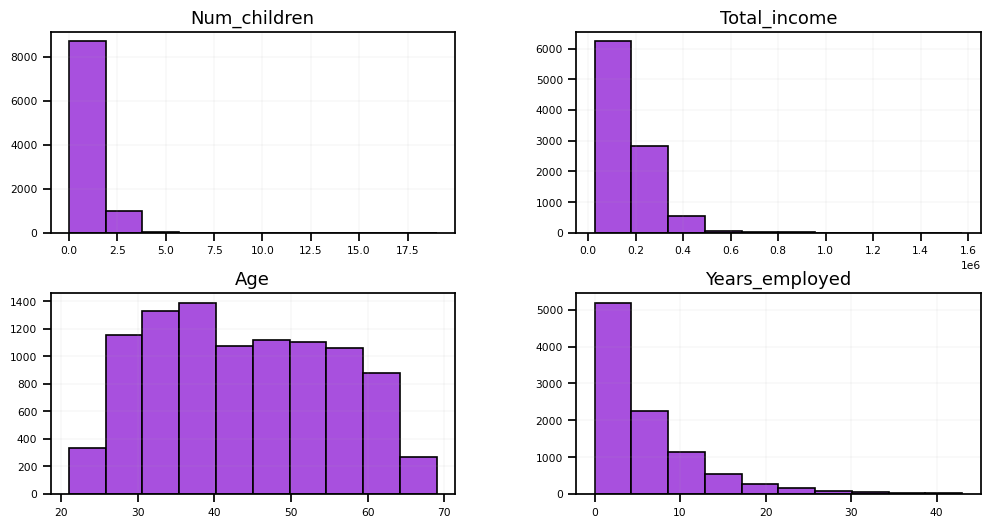

In [ ]:
plt.figure(figsize=(10,10))

cols_to_plot = ["Num_children","Total_income","Age","Years_employed"]
new_df[cols_to_plot].hist(edgecolor='black', linewidth=1.2)
fig=plt.gcf()
fig.set_size_inches(12,6)

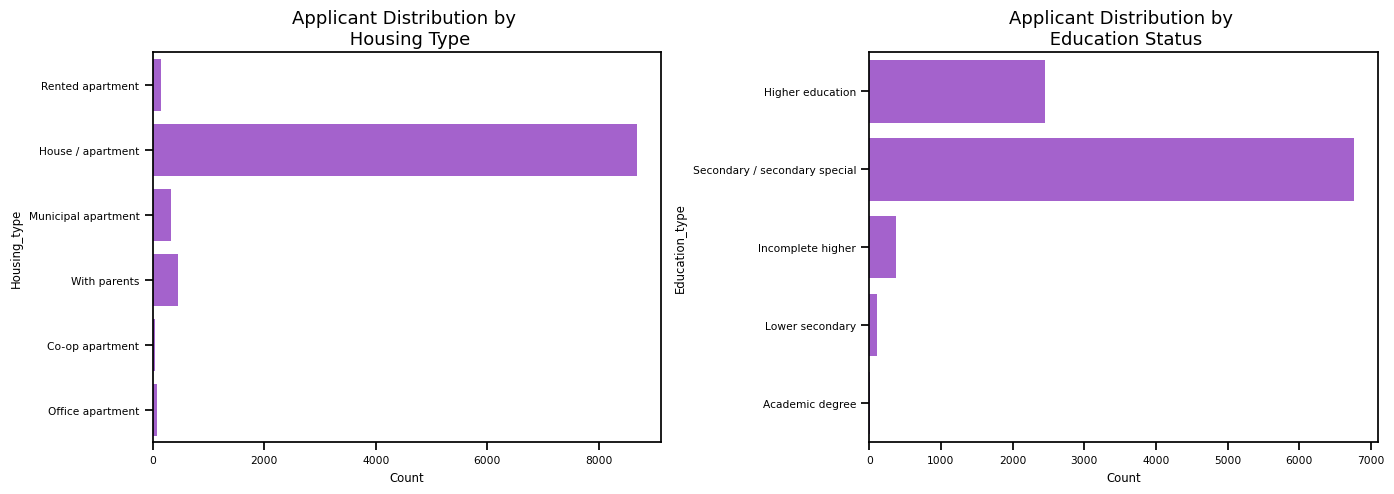

In [ ]:
fig, axes = plt.subplots(1,2)
g1=sns.countplot(y=new_df.Housing_type,linewidth=1.2, ax=axes[0])
g1.set_title("Applicant Distribution by \n Housing Type")
g1.set_xlabel("Count")

g2=sns.countplot(y=new_df.Education_type,linewidth=1.2, ax=axes[1])
g2.set_title("Applicant Distribution by \n Education Status")
g2.set_xlabel("Count")

fig.set_size_inches(14,5)

plt.tight_layout()

plt.show()

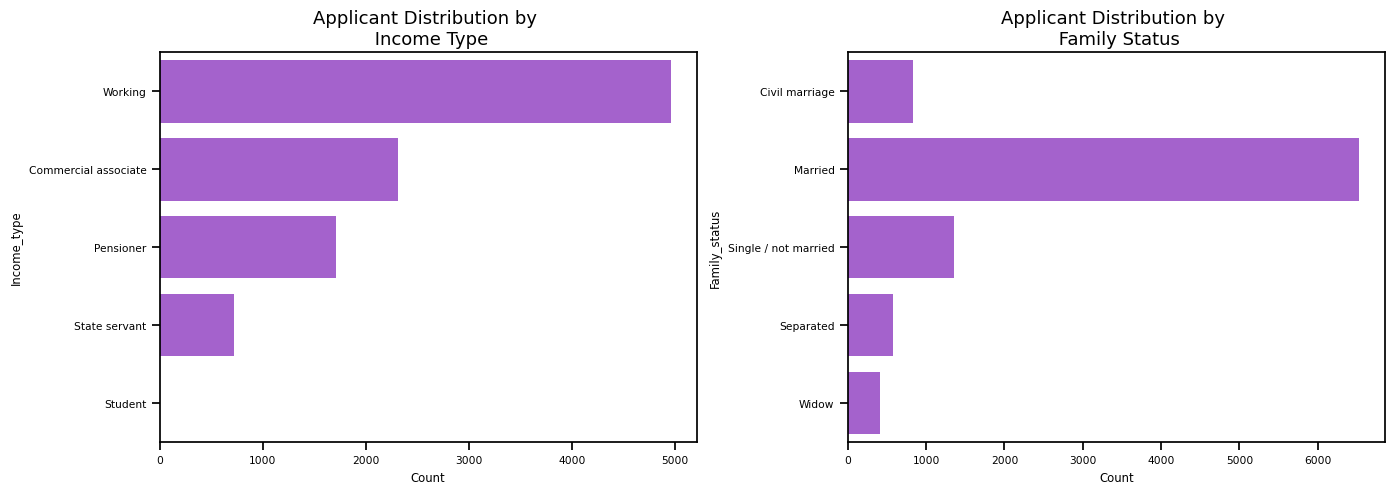

In [ ]:
fig, axes = plt.subplots(1,2)
g1=sns.countplot(y=new_df.Income_type,linewidth=1.2, ax=axes[0])
g1.set_title("Applicant Distribution by \n Income Type")
g1.set_xlabel("Count")

g2=sns.countplot(y=new_df.Family_status,linewidth=1.2, ax=axes[1])
g2.set_title("Applicant Distribution by \n Family Status")
g2.set_xlabel("Count")

fig.set_size_inches(14,5)

plt.tight_layout()

plt.show()

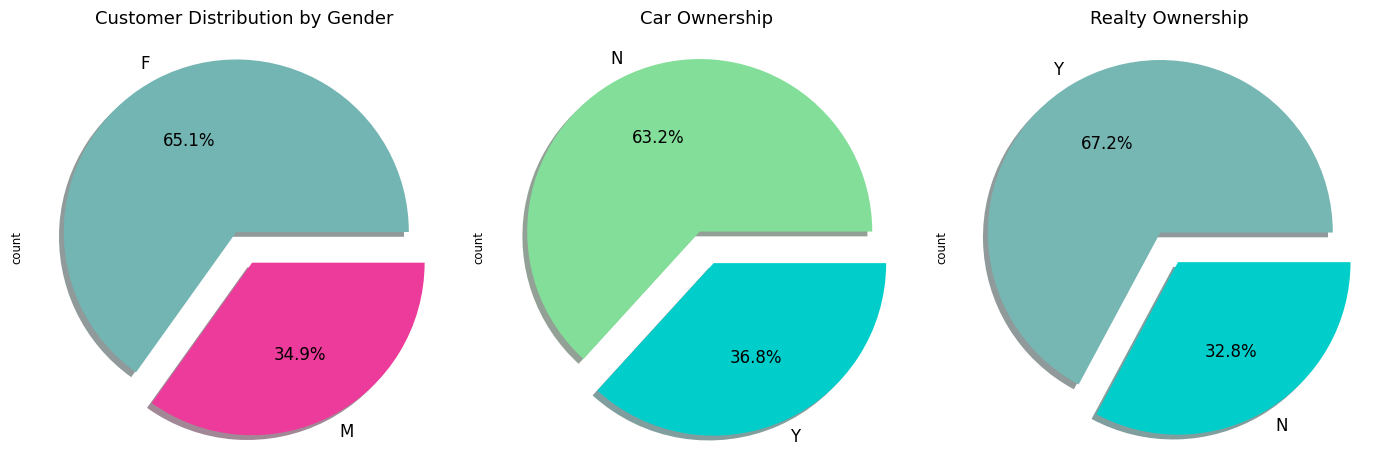

In [ ]:
fig, axes = plt.subplots(1,3)

g1= new_df['Gender'].value_counts().plot.pie(explode=[0.1,0.1],autopct='%1.1f%%',shadow=True, colors=["#73B5B3","#EC3B9A"],textprops = {'fontsize':12}, ax=axes[0])
g1.set_title("Customer Distribution by Gender")

g2= new_df['Own_car'].value_counts().plot.pie(explode=[0.1,0.1],autopct='%1.1f%%',shadow=True,colors=["#82DE99","#01CECB"],textprops = {'fontsize':12}, ax=axes[1])
g2.set_title("Car Ownership")

g3= new_df['Own_property'].value_counts().plot.pie(explode=[0.1,0.1],autopct='%1.1f%%',shadow=True,colors=["#76B6B3","#01CECB"],textprops = {'fontsize':12}, ax=axes[2])
g3.set_title("Realty Ownership")

fig.set_size_inches(14,5)

plt.tight_layout()

plt.show()

In [ ]:
object_columns = new_df.columns[new_df.dtypes =='str'].tolist()
#object columns in dataset

unique_counts = pd.DataFrame.from_records([(col, new_df[object_columns][col].nunique()) for col in new_df[object_columns].columns],
                          columns=['Column_Name', 'Num_Unique']).sort_values(by=['Num_Unique'])

unique_counts
#unique counts for object columns

,Column_Name,Num_Unique


In [ ]:
for i in new_df.columns[(new_df.dtypes == 'object').values].tolist():
  print(i, '\n')
  print(new_df[i].value_counts())
  print("---------------------------------------")

Gender 

Gender
F    6323
M    3386
Name: count, dtype: int64
---------------------------------------
Own_car 

Own_car
N    6139
Y    3570
Name: count, dtype: int64
---------------------------------------
Own_property 

Own_property
Y    6520
N    3189
Name: count, dtype: int64
---------------------------------------
Income_type 

Income_type
Working                 4960
Commercial associate    2312
Pensioner               1712
State servant            722
Student                    3
Name: count, dtype: int64
---------------------------------------
Education_type 

Education_type
Secondary / secondary special    6761
Higher education                 2457
Incomplete higher                 371
Lower secondary                   114
Academic degree                     6
Name: count, dtype: int64
---------------------------------------
Family_status 

Family_status
Married                 6530
Single / not married    1359
Civil marriage           836
Separated                574
Widow    

In [ ]:
new_df["Gender"] = new_df["Gender"].replace(['F','M'],[0, 1])
new_df["Own_car"] = new_df["Own_car"].replace(['Y','N'],[1, 0])
new_df["Own_property"] = new_df["Own_property"].replace(['Y','N'],[1, 0])


In [ ]:
new_df.head(2)

,ID,Gender,Own_car,Own_property,Num_children,Total_income,Income_type,Education_type,Family_status,Housing_type,Work_phone,Phone,Email,Occupation_type,Num_family,Target,Age,Unemployed,Years_employed
0,5008804,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,0,0,Other,2.0,1,33.0,0,12.4
1,5008806,1,1,1,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,0,0,0,Security staff,2.0,0,59.0,0,3.1


In [ ]:
new_df.Income_type.unique()

array(['Working', 'Commercial associate', 'Pensioner', 'State servant',
       'Student'], dtype=object)

In [ ]:
new_df.Family_status.unique()

array(['Civil marriage', 'Married', 'Single / not married', 'Separated',
       'Widow'], dtype=object)

In [ ]:
new_df["Is working"] = new_df["Income_type"].replace(['Working', 'Commercial associate', 'Pensioner', 'State servant',
       'Student'], [1,1,1,0,0])

new_df["Marital_Status"]= new_df["Family_status"].replace(['Civil marriage', 'Married', 'Single / not married', 'Separated',
       'Widow'],[1,1,0,0,0])

In [ ]:
new_df

,ID,Gender,Own_car,Own_property,Num_children,Total_income,Income_type,Education_type,Family_status,Housing_type,...,Phone,Email,Occupation_type,Num_family,Target,Age,Unemployed,Years_employed,Is working,Marital_Status
0,5008804,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,0,0,Other,2.0,1,33.0,0,12.4,1,1
1,5008806,1,1,1,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,0,0,Security staff,2.0,0,59.0,0,3.1,1,1
2,5008808,0,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,1,Sales staff,1.0,0,52.0,0,8.4,1,0
3,5008812,0,0,1,0,283500.0,Pensioner,Higher education,Separated,House / apartment,...,0,0,Other,1.0,0,62.0,1,0.0,1,0
4,5008815,1,1,1,0,270000.0,Working,Higher education,Married,House / apartment,...,1,1,Accountants,2.0,0,46.0,0,2.1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9704,5148694,0,0,0,0,180000.0,Pensioner,Secondary / secondary special,Civil marriage,Municipal apartment,...,0,0,Laborers,2.0,1,56.0,0,0.5,1,1
9705,5149055,0,0,1,0,112500.0,Commercial associate,Secondary / secondary special,Married,House / apartment,...,1,0,Other,2.0,1,43.0,0,7.4,1,1
9706,5149729,1,1,1,0,90000.0,Working,Secondary / secondary special,Married,House / apartment,...,0,0,Other,2.0,1,52.0,0,4.7,1,1
9707,5149838,0,0,1,0,157500.0,Pensioner,Higher education,Married,House / apartment,...,1,1,Medicine staff,2.0,1,34.0,0,3.6,1,1


In [ ]:
education_type = {'Secondary / secondary special':'Secondary',
                     'Lower secondary':'Secondary',
                     'Higher education':'Higher education',
                     'Incomplete higher':'Higher education',
                     'Academic degree':'Academic degree'}

new_df["Education_type"] = new_df["Education_type"].map(education_type)

In [ ]:
new_df.Education_type.value_counts()

,count
Education_type,
Secondary,6875
Higher education,2828
Academic degree,6


In [ ]:
new_df['Household_Size'] = new_df['Num_children'] + new_df['Marital_Status'].apply(lambda x: 2 if x == 1 else 1)

In [ ]:
new_df.head(10)

,ID,Gender,Own_car,Own_property,Num_children,Total_income,Income_type,Education_type,Family_status,Housing_type,...,Email,Occupation_type,Num_family,Target,Age,Unemployed,Years_employed,Is working,Marital_Status,Household_Size
0,5008804,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,0,Other,2.0,1,33.0,0,12.4,1,1,2
1,5008806,1,1,1,0,112500.0,Working,Secondary,Married,House / apartment,...,0,Security staff,2.0,0,59.0,0,3.1,1,1,2
2,5008808,0,0,1,0,270000.0,Commercial associate,Secondary,Single / not married,House / apartment,...,1,Sales staff,1.0,0,52.0,0,8.4,1,0,1
3,5008812,0,0,1,0,283500.0,Pensioner,Higher education,Separated,House / apartment,...,0,Other,1.0,0,62.0,1,0.0,1,0,1
4,5008815,1,1,1,0,270000.0,Working,Higher education,Married,House / apartment,...,1,Accountants,2.0,0,46.0,0,2.1,1,1,2
5,5008819,1,1,1,0,135000.0,Commercial associate,Secondary,Married,House / apartment,...,0,Laborers,2.0,0,49.0,0,3.3,1,1,2
6,5008825,0,1,0,0,130500.0,Working,Higher education,Married,House / apartment,...,0,Accountants,2.0,1,29.0,0,3.0,1,1,2
7,5008830,0,0,1,0,157500.0,Working,Secondary,Married,House / apartment,...,0,Laborers,2.0,1,27.0,0,4.0,1,1,2
8,5008834,0,0,1,1,112500.0,Working,Secondary,Single / not married,House / apartment,...,0,Other,2.0,0,30.0,0,4.4,1,0,2
9,5008836,1,1,1,3,270000.0,Working,Secondary,Married,House / apartment,...,0,Laborers,5.0,0,35.0,0,3.2,1,1,5


In [ ]:
new_df["Years_employed"].value_counts()

,count
Years_employed,
0.0,1697
0.5,130
0.6,117
0.3,115
0.4,110
...,...
0.1,1
35.9,1
35.1,1


In [ ]:
numerical_cols = ["Total_income","Age","Years_employed","Household_Size"]

fig = make_subplots(rows=2, cols=2, start_cell="bottom-left",
                   subplot_titles=("Income", "Age", "Experience", "Family Members Count"))

fig.add_trace(go.Box(x=new_df.Total_income, name='Income',boxmean=True),row=1,col=1)
fig.add_trace(go.Box(x=new_df.Age, name='Age', boxmean=True), row=1, col=2)
fig.add_trace(go.Box(x=new_df.Years_employed, name='Experience', boxmean=True), row=2, col=1)
fig.add_trace(go.Box(x=new_df.Household_Size, name="Family Member Count", boxmean=True),row=2, col=2)

fig.show()


In [ ]:
new_df[(new_df["Years_employed"]>=40)]

,ID,Gender,Own_car,Own_property,Num_children,Total_income,Income_type,Education_type,Family_status,Housing_type,...,Email,Occupation_type,Num_family,Target,Age,Unemployed,Years_employed,Is working,Marital_Status,Household_Size
2442,5037026,0,0,1,0,85500.0,Working,Secondary,Separated,House / apartment,...,0,Other,1.0,0,59.0,0,41.3,1,0,1
2686,5041425,0,1,1,0,202500.0,State servant,Higher education,Single / not married,House / apartment,...,0,Other,1.0,0,61.0,0,41.2,0,0,1
3830,5056142,1,1,0,0,157500.0,Working,Secondary,Married,House / apartment,...,0,Laborers,2.0,0,64.0,0,40.8,1,1,2
5475,5090311,0,1,1,0,162000.0,State servant,Secondary,Married,House / apartment,...,0,Other,2.0,0,61.0,0,41.7,0,1,2
7142,5112905,0,0,1,0,180000.0,Commercial associate,Secondary,Married,House / apartment,...,0,Medicine staff,2.0,0,63.0,0,43.0,1,1,2
7665,5116243,0,0,1,0,315000.0,Working,Secondary,Married,House / apartment,...,0,Medicine staff,2.0,0,61.0,0,40.6,1,1,2
8274,5125725,0,0,1,0,202500.0,Commercial associate,Secondary,Married,House / apartment,...,0,High skill tech staff,2.0,1,63.0,0,40.5,1,1,2
9328,5148702,0,0,1,0,126000.0,Commercial associate,Secondary,Married,House / apartment,...,0,Core staff,2.0,0,62.0,0,42.9,1,1,2


In [ ]:
new_df[(new_df["Household_Size"]>=9)]

,ID,Gender,Own_car,Own_property,Num_children,Total_income,Income_type,Education_type,Family_status,Housing_type,...,Email,Occupation_type,Num_family,Target,Age,Unemployed,Years_employed,Is working,Marital_Status,Household_Size
3922,5061207,1,1,1,14,225000.0,Working,Secondary,Separated,House / apartment,...,0,Drivers,15.0,0,49.0,0,4.6,1,0,15
6840,5105054,0,0,1,19,112500.0,Working,Secondary,Single / not married,House / apartment,...,0,Waiters/barmen staff,20.0,0,30.0,0,5.1,1,0,20
8094,5118330,0,0,0,7,157500.0,Working,Secondary,Married,House / apartment,...,0,Cleaning staff,9.0,1,38.0,0,4.5,1,1,9


In [ ]:
new_df.drop(new_df[(new_df["Household_Size"]>=9)].index, axis=0, inplace = True)

<Axes: xlabel='Num_children'>

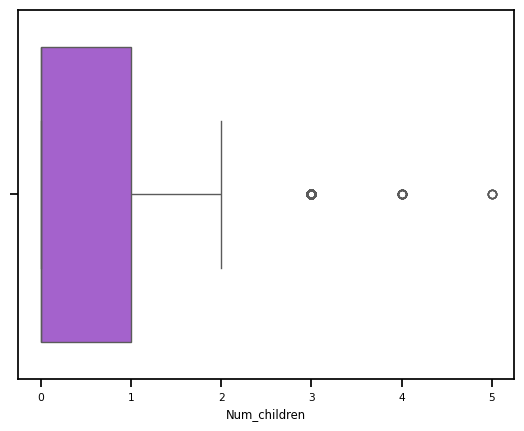

In [ ]:
sns.boxplot(x= new_df['Num_children'])

In [ ]:
new_df['Num_children'].value_counts()

,count
Num_children,
0,6819
1,1886
2,852
3,126
4,18
5,5


In [ ]:
new_df.columns

Index(['ID', 'Gender', 'Own_car', 'Own_property', 'Num_children',
       'Total_income', 'Income_type', 'Education_type', 'Family_status',
       'Housing_type', 'Work_phone', 'Phone', 'Email', 'Occupation_type',
       'Num_family', 'Target', 'Age', 'Unemployed', 'Years_employed',
       'Is working', 'Marital_Status', 'Household_Size'],
      dtype='object')

In [ ]:
new_df = new_df.loc[:, ['ID', 'Gender', 'Own_car', 'Own_property', 'Num_children',
       'Total_income', 'Income_type', 'Education_type', 'Family_status',
       'Housing_type', 'Work_phone', 'Phone', 'Email', 'Occupation_type',
       'Num_family', 'Age', 'Unemployed', 'Years_employed',
       'Is working', 'Marital_Status', 'Household_Size', 'Target']]

In [ ]:
new_df.head()

,ID,Gender,Own_car,Own_property,Num_children,Total_income,Income_type,Education_type,Family_status,Housing_type,...,Email,Occupation_type,Num_family,Age,Unemployed,Years_employed,Is working,Marital_Status,Household_Size,Target
0,5008804,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,0,Other,2.0,33.0,0,12.4,1,1,2,1
1,5008806,1,1,1,0,112500.0,Working,Secondary,Married,House / apartment,...,0,Security staff,2.0,59.0,0,3.1,1,1,2,0
2,5008808,0,0,1,0,270000.0,Commercial associate,Secondary,Single / not married,House / apartment,...,1,Sales staff,1.0,52.0,0,8.4,1,0,1,0
3,5008812,0,0,1,0,283500.0,Pensioner,Higher education,Separated,House / apartment,...,0,Other,1.0,62.0,1,0.0,1,0,1,0
4,5008815,1,1,1,0,270000.0,Working,Higher education,Married,House / apartment,...,1,Accountants,2.0,46.0,0,2.1,1,1,2,0


In [ ]:
new_df.head()

,ID,Gender,Own_car,Own_property,Num_children,Total_income,Income_type,Education_type,Family_status,Housing_type,...,Email,Occupation_type,Num_family,Age,Unemployed,Years_employed,Is working,Marital_Status,Household_Size,Target
0,5008804,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,0,Other,2.0,33.0,0,12.4,1,1,2,1
1,5008806,1,1,1,0,112500.0,Working,Secondary,Married,House / apartment,...,0,Security staff,2.0,59.0,0,3.1,1,1,2,0
2,5008808,0,0,1,0,270000.0,Commercial associate,Secondary,Single / not married,House / apartment,...,1,Sales staff,1.0,52.0,0,8.4,1,0,1,0
3,5008812,0,0,1,0,283500.0,Pensioner,Higher education,Separated,House / apartment,...,0,Other,1.0,62.0,1,0.0,1,0,1,0
4,5008815,1,1,1,0,270000.0,Working,Higher education,Married,House / apartment,...,1,Accountants,2.0,46.0,0,2.1,1,1,2,0


In [ ]:
new_df

,ID,Gender,Own_car,Own_property,Num_children,Total_income,Income_type,Education_type,Family_status,Housing_type,...,Email,Occupation_type,Num_family,Age,Unemployed,Years_employed,Is working,Marital_Status,Household_Size,Target
0,5008804,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,0,Other,2.0,33.0,0,12.4,1,1,2,1
1,5008806,1,1,1,0,112500.0,Working,Secondary,Married,House / apartment,...,0,Security staff,2.0,59.0,0,3.1,1,1,2,0
2,5008808,0,0,1,0,270000.0,Commercial associate,Secondary,Single / not married,House / apartment,...,1,Sales staff,1.0,52.0,0,8.4,1,0,1,0
3,5008812,0,0,1,0,283500.0,Pensioner,Higher education,Separated,House / apartment,...,0,Other,1.0,62.0,1,0.0,1,0,1,0
4,5008815,1,1,1,0,270000.0,Working,Higher education,Married,House / apartment,...,1,Accountants,2.0,46.0,0,2.1,1,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9704,5148694,0,0,0,0,180000.0,Pensioner,Secondary,Civil marriage,Municipal apartment,...,0,Laborers,2.0,56.0,0,0.5,1,1,2,1
9705,5149055,0,0,1,0,112500.0,Commercial associate,Secondary,Married,House / apartment,...,0,Other,2.0,43.0,0,7.4,1,1,2,1
9706,5149729,1,1,1,0,90000.0,Working,Secondary,Married,House / apartment,...,0,Other,2.0,52.0,0,4.7,1,1,2,1
9707,5149838,0,0,1,0,157500.0,Pensioner,Higher education,Married,House / apartment,...,1,Medicine staff,2.0,34.0,0,3.6,1,1,2,1


In [ ]:
new_df.drop(["ID"], axis= 1, inplace= True)

In [ ]:
new_df.drop(["Email"], axis= 1, inplace= True)

In [ ]:
new_df.drop(["Phone"], axis= 1, inplace= True)

In [ ]:
new_df.drop(["Work_phone"], axis= 1, inplace= True)

In [ ]:
new_df.drop(["Housing_type"], axis=1, inplace= True)

In [ ]:
new_df.drop(["Family_status"], axis=1, inplace= True)

In [ ]:
new_df.drop(["Unemployed"], axis= 1, inplace= True)

In [ ]:
new_df.head()

,Gender,Own_car,Own_property,Num_children,Total_income,Income_type,Education_type,Occupation_type,Num_family,Age,Years_employed,Is working,Marital_Status,Household_Size,Target
0,1,1,1,0,427500.0,Working,Higher education,Other,2.0,33.0,12.4,1,1,2,1
1,1,1,1,0,112500.0,Working,Secondary,Security staff,2.0,59.0,3.1,1,1,2,0
2,0,0,1,0,270000.0,Commercial associate,Secondary,Sales staff,1.0,52.0,8.4,1,0,1,0
3,0,0,1,0,283500.0,Pensioner,Higher education,Other,1.0,62.0,0.0,1,0,1,0
4,1,1,1,0,270000.0,Working,Higher education,Accountants,2.0,46.0,2.1,1,1,2,0


In [ ]:
new_df.columns

Index(['Gender', 'Own_car', 'Own_property', 'Num_children', 'Total_income',
       'Income_type', 'Education_type', 'Occupation_type', 'Num_family', 'Age',
       'Years_employed', 'Is working', 'Marital_Status', 'Household_Size',
       'Target'],
      dtype='object')

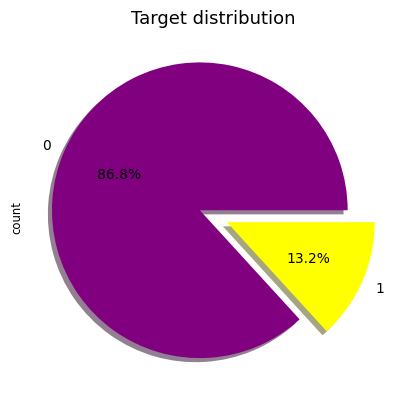

In [ ]:
new_df['Target'].value_counts().plot.pie(explode=[0.1,0.1],autopct='%1.1f%%',shadow=True,colors=['purple', 'yellow'],textprops = {'fontsize':10}).set_title("Target distribution")

plt.show()


In [ ]:
colname=[]
for x in new_df.columns:
  if new_df[x].dtypes == 'object':
    colname.append(x)
colname

['Income_type', 'Education_type', 'Occupation_type']

In [ ]:
#Converting the categorical data into numerical data
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

for x in colname:
    new_df[x]=le.fit_transform(new_df[x])
    le_name_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print('Feature', x)
    print('mapping', le_name_mapping)

Feature Income_type
mapping {'Commercial associate': np.int64(0), 'Pensioner': np.int64(1), 'State servant': np.int64(2), 'Student': np.int64(3), 'Working': np.int64(4)}
Feature Education_type
mapping {'Academic degree': np.int64(0), 'Higher education': np.int64(1), 'Secondary': np.int64(2)}
Feature Occupation_type
mapping {'Accountants': np.int64(0), 'Cleaning staff': np.int64(1), 'Cooking staff': np.int64(2), 'Core staff': np.int64(3), 'Drivers': np.int64(4), 'HR staff': np.int64(5), 'High skill tech staff': np.int64(6), 'IT staff': np.int64(7), 'Laborers': np.int64(8), 'Low-skill Laborers': np.int64(9), 'Managers': np.int64(10), 'Medicine staff': np.int64(11), 'Other': np.int64(12), 'Private service staff': np.int64(13), 'Realty agents': np.int64(14), 'Sales staff': np.int64(15), 'Secretaries': np.int64(16), 'Security staff': np.int64(17), 'Waiters/barmen staff': np.int64(18)}


In [ ]:
new_df.dtypes

,0
Gender,int64
Own_car,int64
Own_property,int64
Num_children,int64
Total_income,float64
Income_type,int64
Education_type,int64
Occupation_type,int64
Num_family,float64
Age,float64


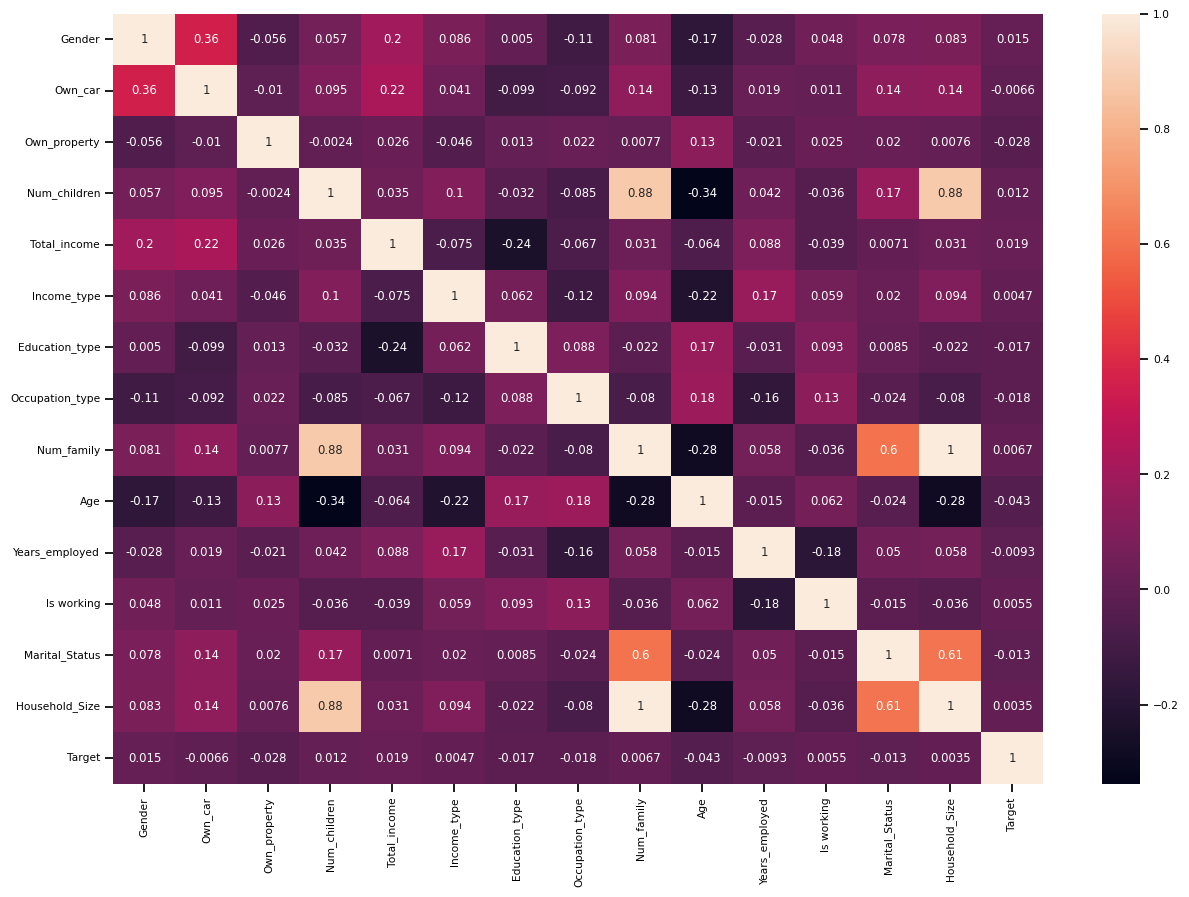

In [ ]:
plt.figure(figsize = (15, 10))
corr= new_df.corr()
sns.heatmap(corr, annot=True)
plt.show();

In [ ]:
X = new_df.iloc[:,0:-1]
Y = new_df.iloc[:, -1]

In [ ]:
print(X.shape)
print(Y.shape)

(9706, 14)
(9706,)


In [ ]:
from sklearn.model_selection import train_test_split
#<1000=in range of 80-20  &  >1000=in range of 70-30

#Split the data into test and train

X_train , X_test, Y_train, Y_test= train_test_split(X, Y, test_size = 0.2 , random_state=10)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(7764, 14)
(1942, 14)
(7764,)
(1942,)


Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
#create the model
classifier = LogisticRegression()
# train the model
classifier.fit(X_train , Y_train)
Y_pred = classifier.predict(X_test)

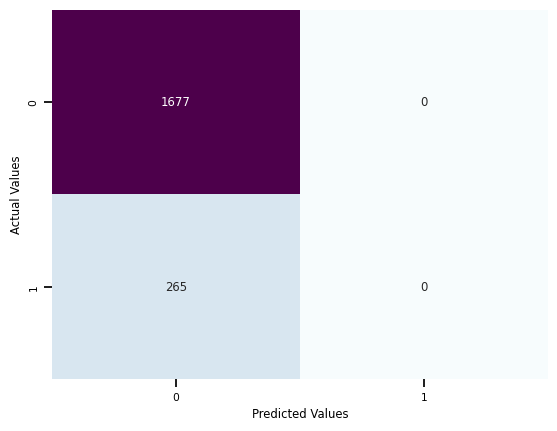

Classification report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.93      1677
           1       0.00      0.00      0.00       265

    accuracy                           0.86      1942
   macro avg       0.43      0.50      0.46      1942
weighted avg       0.75      0.86      0.80      1942

Accuracy of the model:  0.8635427394438723


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model_KNN = KNeighborsClassifier(n_neighbors= 4, metric='manhattan')

#euclidean,manhattan,minkowski
#fit the model on the data and predict the values
model_KNN.fit(X_train,Y_train)

Y_pred=model_KNN.predict(X_test)

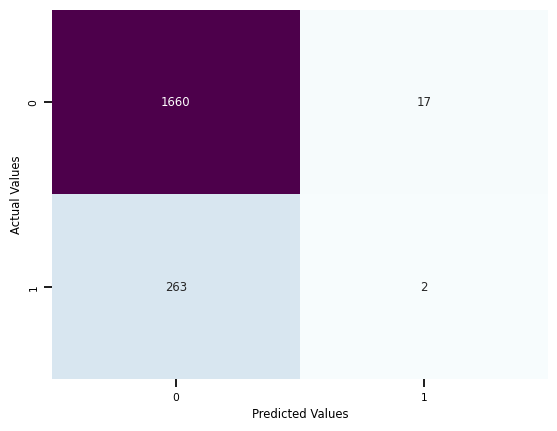

Classification report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92      1677
           1       0.11      0.01      0.01       265

    accuracy                           0.86      1942
   macro avg       0.48      0.50      0.47      1942
weighted avg       0.76      0.86      0.80      1942

Accuracy of the model:  0.8558187435633368


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)